In [3]:
def tp_fp_tn_fn(a, b):
    tp = (a == 1) & (b == 1)
    fp = (a == 0) & (b == 1) 
    tn = (a == 0) & (b == 0)
    fn = (a == 1) & (b == 0)
    return tp.sum(), fp.sum(), tn.sum(), fn.sum()

def batch_tp_fp_tn_fn(a_batch, b_batch):
    tp_total = fp_total = tn_total = fn_total = 0
    for a, b in zip(a_batch, b_batch):
        tp, fp, tn, fn = tp_fp_tn_fn(a, b)
        tp_total += tp
        fp_total += fp
        tn_total += tn
        fn_total += fn
    return tp_total, fp_total, tn_total, fn_total

def f_beta(beta, tp, fp , fn):
    tp_term = ((1 + beta**2) * tp)
    return tp_term / (tp_term + (beta**2)*fn + fp)

def batch_metrics_with_confidence(a_batch, b_batch, conf_range):
    out = {}
    for c in conf_range:
        cur_b_batch = (b_batch >= c).astype(float)
        tp, fp, tn, fn = batch_tp_fp_tn_fn(a_batch, cur_b_batch)
        total = tp + fp + tn + fn
        out[c] = {
            'tp': tp,
            'fp': fp,
            'tn': tn,
            'fn': fn,
            'tpr': tp / (tp + fn),
            'fpr': fp / (fp + tn),
            'acc': (tp + tn) / total,
            'precision': tp / (tp + fp),
            'recall': tp / (tp + fn),
            'f1': f_beta(1, tp, fp, fn),
            'f2': f_beta(2, tp, fp, fn)
        }
    return out

In [ ]:
import pickle
import glob
from tqdm.auto import tqdm

datapoints = []
for dp_file in tqdm(glob.glob('data_dir_gwproc/*.pkl')):
    with open(dp_file, 'rb') as f:
        datapoints.append(pickle.load(f))

  0%|          | 0/1726 [00:00<?, ?it/s]

In [4]:
import numpy as np
out = batch_metrics_with_confidence(np.array(list(map(lambda x: x['true_state_array'], datapoints))),
                                    np.array(list(map(lambda x: x['est_state_array_prob'], datapoints))),
                                    np.linspace(0, 1, num=11))

/scratch/slurm-47569/ipykernel_3389597/1544673226.py:36: RuntimeWarning: invalid value encountered in scalar divide
  'precision': tp / (tp + fp),


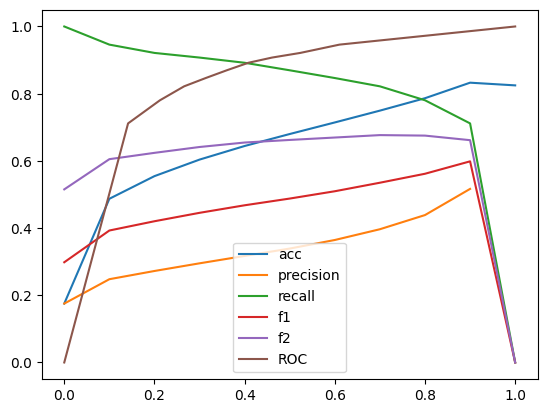

In [5]:
import matplotlib.pyplot as plt
plt.plot(np.linspace(0, 1, num=11), list(map(lambda x: x['acc'], out.values())), label='acc')
plt.plot(np.linspace(0, 1, num=11), list(map(lambda x: x['precision'], out.values())), label='precision')
plt.plot(np.linspace(0, 1, num=11), list(map(lambda x: x['recall'], out.values())), label='recall')
plt.plot(np.linspace(0, 1, num=11), list(map(lambda x: x['f1'], out.values())), label='f1')
plt.plot(np.linspace(0, 1, num=11), list(map(lambda x: x['f2'], out.values())), label='f2')
plt.plot(list(map(lambda x: x['fpr'], out.values())) + [0], list(map(lambda x: x['tpr'], out.values())) + [0], label='ROC')
plt.legend()

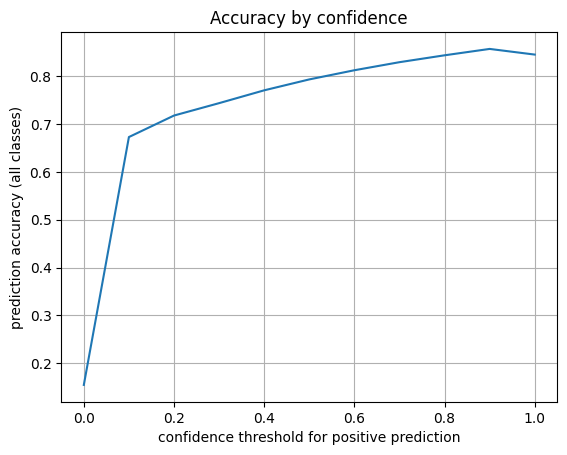

In [5]:
plt.title('Accuracy by confidence')
plt.plot(np.linspace(0, 1, num=11), list(map(lambda x: x['acc'], out.values())))
plt.xlabel('confidence threshold for positive prediction')
plt.ylabel('prediction accuracy (all classes)')
plt.grid()
plt.show()

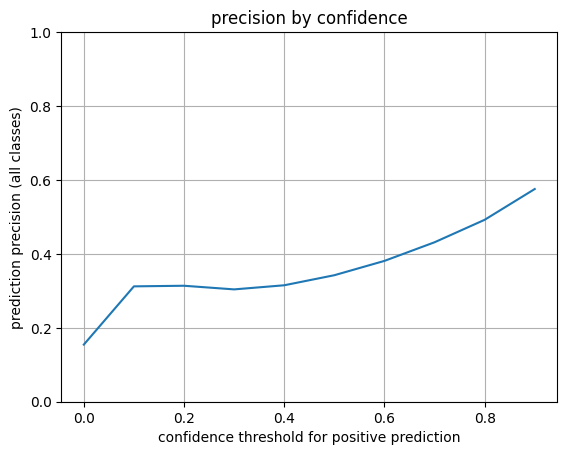

In [7]:
plt.title('precision by confidence')
plt.ylim((0, 1))
plt.plot(np.linspace(0, 1, num=11), list(map(lambda x: x['precision'], out.values())))
plt.xlabel('confidence threshold for positive prediction')
plt.ylabel('prediction precision (all classes)')
plt.grid()
plt.show()

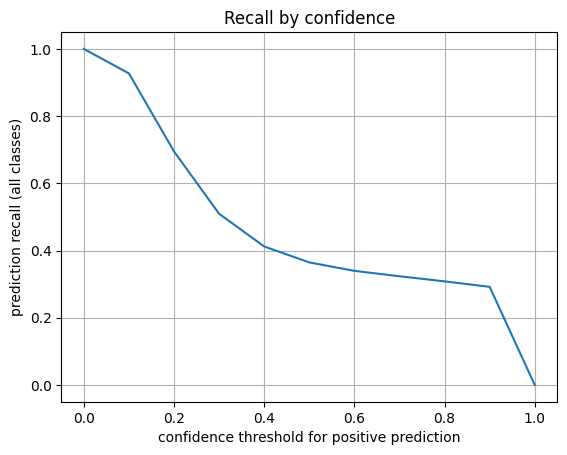

In [8]:
plt.title('Recall by confidence')
plt.plot(np.linspace(0, 1, num=11), list(map(lambda x: x['recall'], out.values())))
plt.xlabel('confidence threshold for positive prediction')
plt.ylabel('prediction recall (all classes)')
plt.grid()
plt.show()

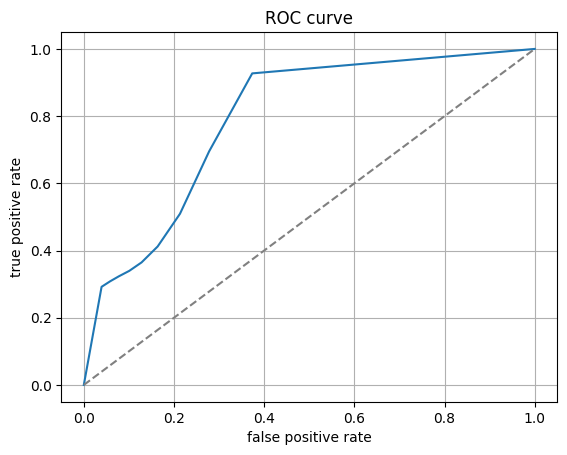

In [9]:
plt.title('ROC curve')
plt.plot(list(map(lambda x: x['fpr'], out.values())) + [0], list(map(lambda x: x['tpr'], out.values())) + [0])
plt.plot(np.linspace(0, 1, num=11), np.linspace(0, 1, num=11), color='gray', linestyle='--')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.grid()
plt.show()

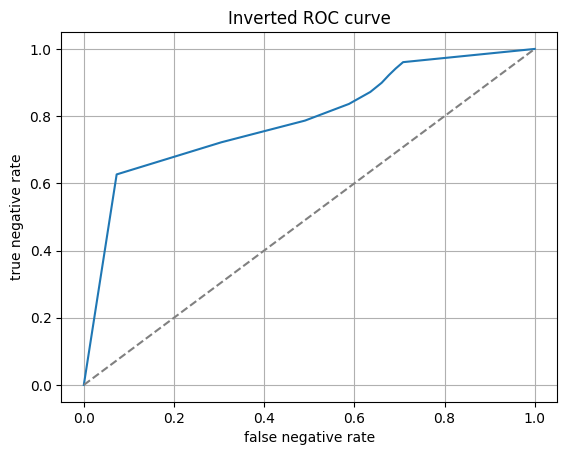

In [10]:
plt.title('Inverted ROC curve')
plt.plot(list(map(lambda x: x['fn'] / (x['fn'] + x['tp']), out.values())), list(map(lambda x: x['tn'] / (x['tn'] + x['fp']), out.values())))
plt.plot(np.linspace(0, 1, num=11), np.linspace(0, 1, num=11), color='gray', linestyle='--')
plt.xlabel('false negative rate')
plt.ylabel('true negative rate')
plt.grid()
plt.show()